# 01 -- Explore the data

Sanity check before building anything: load a few downloaded SpaceNet chips and their
building-footprint polygons, and confirm the labels actually line up with real buildings
in the image.

**Prerequisite:** `python scripts/download_data.py --n 300` (or however many you want)
run first, from the repo root.

In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt
import rasterio
from rasterio.plot import reshape_as_image


## Load one chip and its labels

In [2]:
chip_id = 1

with rasterio.open(f'../data/raw/images/img{chip_id}.tif') as src:
    image = reshape_as_image(src.read([1, 2, 3]))
    height, width = src.shape
    transform = src.transform
    crs = src.crs

buildings = gpd.read_file(f'../data/raw/labels/img{chip_id}.geojson')

print(f'image shape: {height}x{width}, CRS: {crs}')
print(f'buildings in this chip: {len(buildings)}')
print(f'label CRS: {buildings.crs}')


image shape: 650x650, CRS: EPSG:4326
buildings in this chip: 16
label CRS: EPSG:4326


## Plot the image with polygons overlaid

The actual sanity check: do the polygons visibly land on real buildings? SpaceNet's
own labels are generally clean, but always look before training on anything.

16 raw geometries -> 15 real polygons


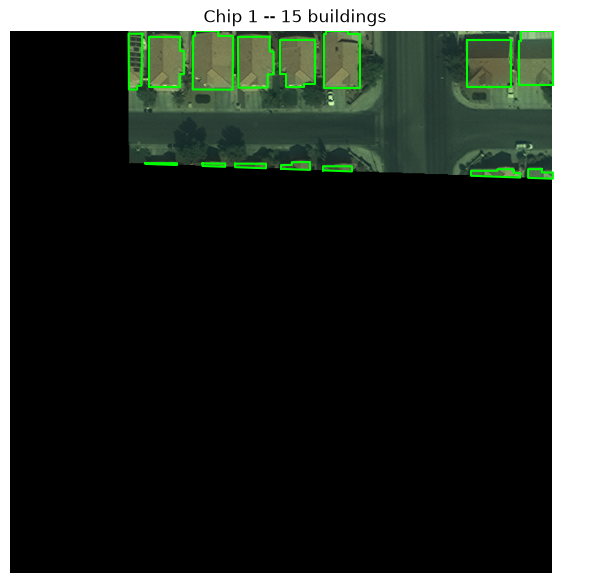

In [3]:
import sys
sys.path.insert(0, '..')
from src.labels import filter_polygon_geometries


def exterior_rings(geom):
    """Polygon and MultiPolygon both survive filter_polygon_geometries
    (both are real buildings -- a MultiPolygon is just one building
    split into disjoint parts), but only Polygon has a bare
    .exterior; MultiPolygon needs one per part."""
    if geom.geom_type == 'Polygon':
        yield geom.exterior
    else:
        for part in geom.geoms:
            yield part.exterior


def normalize(img):
    img = img.astype('float32')
    return (img - img.min()) / (img.max() - img.min() + 1e-9)


# filter_polygon_geometries drops the occasional degenerate Point
# label SpaceNet includes -- live-observed: 1 in 594 across a real
# 20-chip sample. A Point has no .exterior to plot (and would
# produce a meaningless zero-area YOLO box downstream), so it must
# be filtered before either label pipeline touches it.
valid_geoms = filter_polygon_geometries(buildings.geometry)
print(f'{len(buildings)} raw geometries -> {len(valid_geoms)} real polygons')

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(normalize(image))

# Plot each building polygon in pixel space, via the raster's own inverse transform --
# the same conversion src/labels.py's polygon_to_yolo_box does, checked here visually.
inv = ~transform
for geom in valid_geoms:
    for ring in exterior_rings(geom):
        xs, ys = ring.coords.xy
        pixel_coords = [inv @ (x, y) for x, y in zip(xs, ys)]
        px = [c[0] for c in pixel_coords]
        py = [c[1] for c in pixel_coords]
        ax.plot(px, py, color='lime', linewidth=1.5)

ax.set_title(f'Chip {chip_id} -- {len(valid_geoms)} buildings')
ax.axis('off')
plt.tight_layout()
plt.show()


## Look at several chips at once

One chip could get lucky; a handful is a better sanity check.

20 chips downloaded: [1, 10, 101, 1002, 1003, 1004, 1006, 1007, 1009, 1010]...


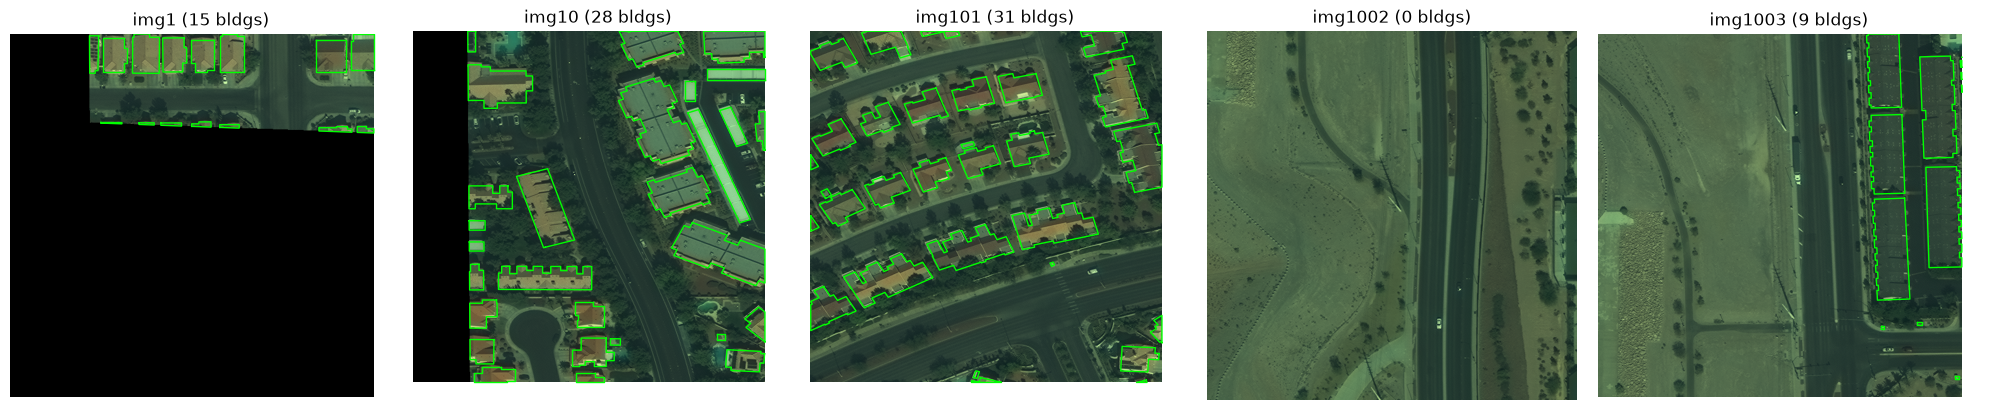

In [4]:
import glob
import os

available_ids = sorted(
    int(os.path.basename(p).replace('img', '').replace('.tif', ''))
    for p in glob.glob('../data/raw/images/img*.tif')
)
print(f'{len(available_ids)} chips downloaded: {available_ids[:10]}...')

sample_ids = available_ids[:5]
fig, axes = plt.subplots(1, len(sample_ids), figsize=(4 * len(sample_ids), 4))
for ax, cid in zip(axes, sample_ids):
    with rasterio.open(f'../data/raw/images/img{cid}.tif') as src:
        img = normalize(reshape_as_image(src.read([1, 2, 3])))
        inv = ~src.transform
    gdf = gpd.read_file(f'../data/raw/labels/img{cid}.geojson')
    valid = filter_polygon_geometries(gdf.geometry)
    ax.imshow(img)
    for geom in valid:
        for ring in exterior_rings(geom):
            xs, ys = ring.coords.xy
            pts = [inv @ (x, y) for x, y in zip(xs, ys)]
            ax.plot([p[0] for p in pts], [p[1] for p in pts], color='lime', linewidth=1)
    ax.set_title(f'img{cid} ({len(valid)} bldgs)')
    ax.axis('off')
plt.tight_layout()
plt.show()


## Done when

- [x] At least 5 chips plotted with their polygon overlays, and they visibly match
  real buildings in the image.
- [x] Image CRS and label CRS confirmed to match (both EPSG:4326 for SpaceNet).